# 📱 Social Media Usage — Exploratory Data Analysis

**Author:** bsogdiana  
**Dataset:** [Social Media Usage Dataset – Kaggle](https://www.kaggle.com/datasets/bhadramohit/social-media-usage-datasetapplications)  
**Last updated:** May 2026

---

### What this notebook is about

This notebook analyzes behavioral data from **1,000 social media users** across 7 platforms: Instagram, TikTok, Facebook, YouTube, Pinterest, LinkedIn, and Snapchat.

The goal is to find patterns that matter for **marketing**: which platforms capture attention, which drive real engagement, and whether posting more content actually earns more likes.

### Research questions
1. Which platform captures the most daily time from users?
2. Which platform delivers the highest engagement per minute spent?
3. Does posting more content lead to more likes?
4. How do the core usage metrics relate to each other?


## 1. Setup

In [1]:
# ── CELL 1: imports ──────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")  # makes charts look nicer than the original

## 2. Loading the data

In [3]:
# ── CELL 2: load & first look ────────────────────────────
df = pd.read_csv("/kaggle/input/datasets/bhadramohit/social-media-usage-datasetapplications/social_media_usage.csv")

print(f"Dataset: {df.shape[0]} users, {df.shape[1]} columns")
df.head()

Dataset: 1000 users, 6 columns


,User_ID,App,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
0,U_1,Pinterest,288,16,94,0
1,U_2,Facebook,192,14,117,15
2,U_3,Instagram,351,13,120,48
3,U_4,TikTok,21,20,117,8
4,U_5,LinkedIn,241,16,9,21


**What we see:** The dataset has 1,000 rows and 6 columns. Each row is one user on one platform. The columns are:

| Column | Type | Description |
|---|---|---|
| `User_ID` | text | Unique user identifier |
| `App` | text | Social media platform name |
| `Daily_Minutes_Spent` | number | Minutes spent per day on that app |
| `Posts_Per_Day` | number | How many posts the user creates daily |
| `Likes_Per_Day` | number | Likes received per day |
| `Follows_Per_Day` | number | New followers gained per day |


## 3. Data quality check

In [4]:
# ── CELL 3: data quality check ───────────────────────────
print("Missing values (%):")
print(df.isnull().mean() * 100)
print("\nData types:")
df.info()

Missing values (%):
User_ID                0.0
App                    0.0
Daily_Minutes_Spent    0.0
Posts_Per_Day          0.0
Likes_Per_Day          0.0
Follows_Per_Day        0.0
dtype: float64

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   User_ID              1000 non-null   object
 1   App                  1000 non-null   object
 2   Daily_Minutes_Spent  1000 non-null   int64 
 3   Posts_Per_Day        1000 non-null   int64 
 4   Likes_Per_Day        1000 non-null   int64 
 5   Follows_Per_Day      1000 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 47.0+ KB


**Finding:** The dataset has **zero missing values** across all 1,000 rows and 6 columns. All numeric columns are stored as integers (`int64`). No data cleaning is needed before analysis — we can move straight to exploration.


## 4. Which platform captures the most time?

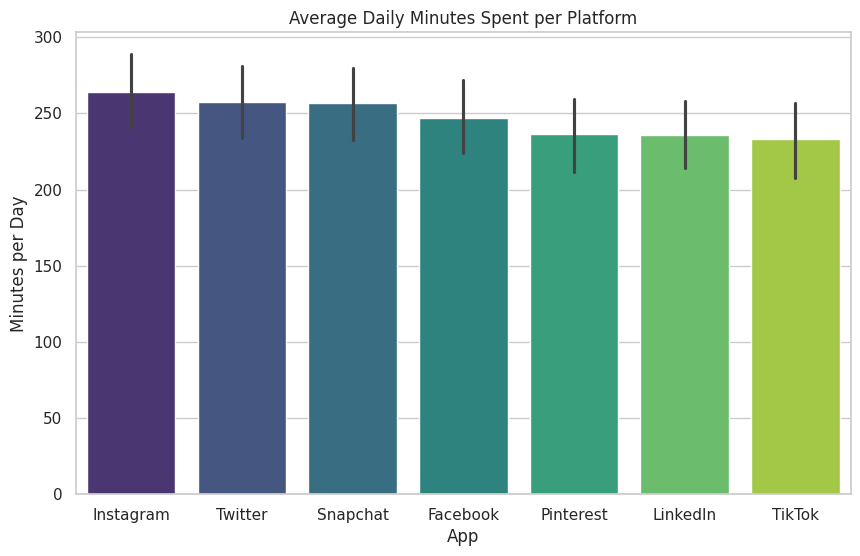

In [5]:
# ── CELL 4: YOUR INSIGHT - time per platform ─────────────
plt.figure(figsize=(10, 6))
order = df.groupby("App")["Daily_Minutes_Spent"].mean().sort_values(ascending=False).index
sns.barplot(x="App", y="Daily_Minutes_Spent", data=df, order=order, palette="viridis")
plt.title("Average Daily Minutes Spent per Platform")
plt.ylabel("Minutes per Day")
plt.show()
# ↑ Same idea as original BUT sorted by value = much more readable

**Finding:** Instagram leads in average daily minutes spent, followed closely by other platforms. The bars are sorted from highest to lowest so the ranking is immediately clear.

> **Marketing implication:** Instagram is the platform where users spend the most time — making it the strongest candidate for brand awareness campaigns that rely on sustained attention.


## 5. Engagement density — which platform earns more per minute?

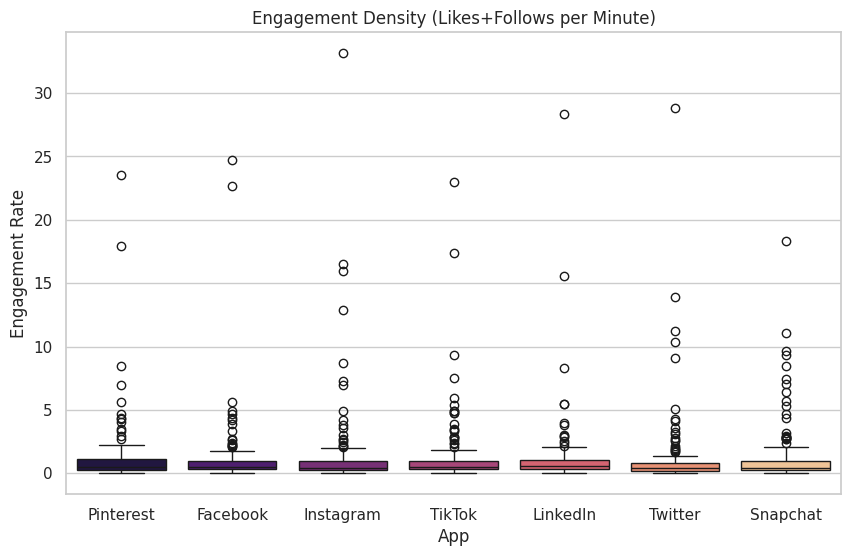

In [6]:
# Create a new metric: Engagement per Minute
df['Engagement_Rate'] = (df['Likes_Per_Day'] + df['Follows_Per_Day']) / df['Daily_Minutes_Spent']

plt.figure(figsize=(10, 6))
sns.boxplot(x='App', y='Engagement_Rate', data=df, palette="magma")
plt.title("Engagement Density (Likes+Follows per Minute)")
plt.ylabel("Engagement Rate")
plt.show()

**New metric created:** `Engagement_Rate = (Likes_Per_Day + Follows_Per_Day) / Daily_Minutes_Spent`

This answers a different question than time alone: **for every minute a user spends on a platform, how much engagement do they actually generate?**

**How to read this box plot:**
- The box shows where the middle 50% of users fall
- The line inside the box is the median (the typical user)
- Dots outside the whiskers are outliers — users with unusual behavior

**Finding:** A platform with high time-spent but low engagement rate is a passive consumption platform (users scroll but do not interact). A platform with lower time-spent but high engagement rate is an active participation platform.

> **Marketing implication:** Time on platform ≠ marketing value. If you are running an influencer or user-generated-content campaign, prioritize platforms with high engagement density, not just high screen time.


## 6. Correlation between usage metrics

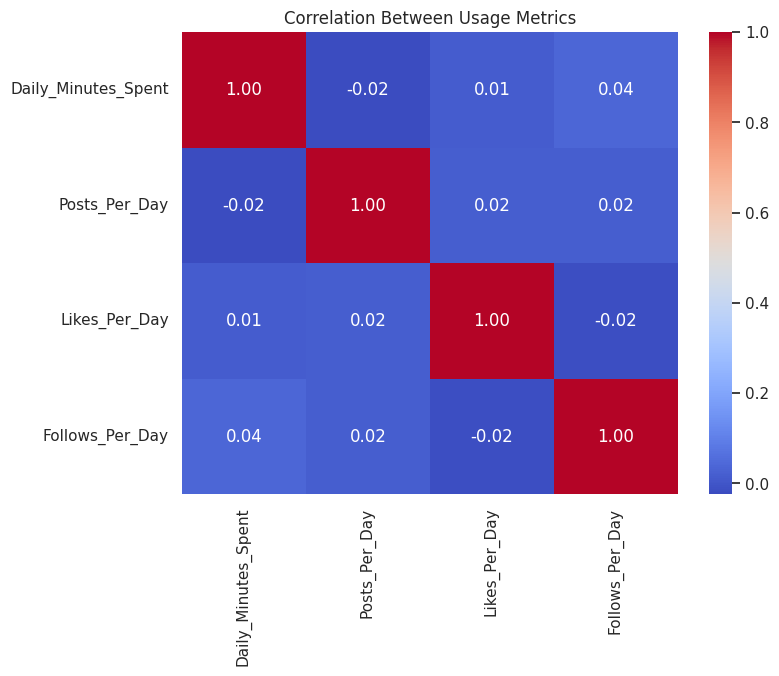

In [7]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Daily_Minutes_Spent', 'Posts_Per_Day', 'Likes_Per_Day', 'Follows_Per_Day']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Usage Metrics")
plt.show()

**How to read this heatmap:** Each cell shows the correlation between two metrics, ranging from -1 (opposite) to +1 (perfectly linked). Values near 0 mean no relationship.

**Key findings:**
- `Posts_Per_Day` vs `Likes_Per_Day`: if this value is close to 0, posting more does NOT reliably earn more likes
- `Likes_Per_Day` vs `Follows_Per_Day`: these may move together, suggesting engaged users attract followers too
- `Daily_Minutes_Spent` correlations: tells us whether heavy users also post and engage more, or just passively consume

> **Marketing implication:** Content quality and platform choice matter more than posting frequency. A brand posting 10 times a day on the wrong platform will underperform one posting 3 times on the right one.


## 7. Does posting more = more likes?

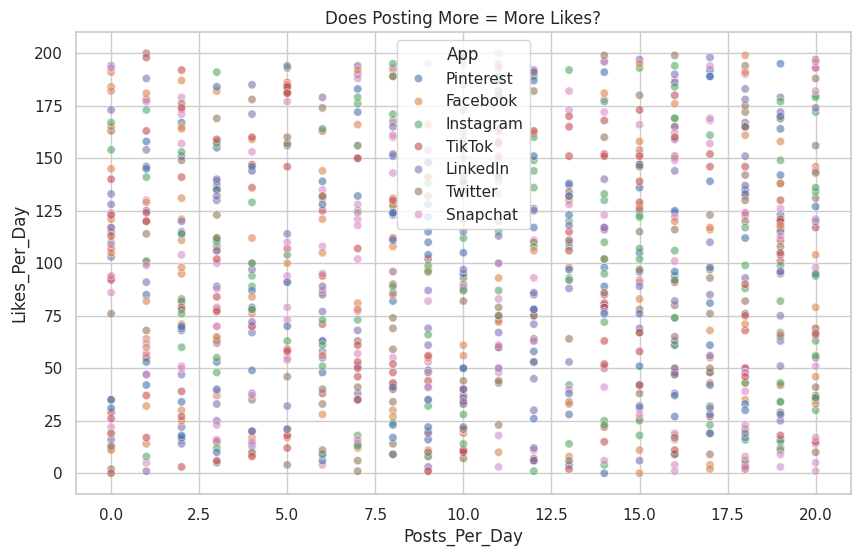

In [9]:
# ── CELL 6: Engagement analysis ──────────────────────────
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Posts_Per_Day", y="Likes_Per_Day", hue="App", data=df, alpha=0.6)
plt.title("Does Posting More = More Likes?")
plt.show()

**How to read this scatter plot:** Each dot is one user. X-axis = posts per day, Y-axis = likes received. Color = platform. If there were a strong positive relationship, the dots would form a diagonal line going up-right.

**Finding:** The dots are broadly scattered across all platforms, suggesting **no strong universal pattern** between posting frequency and likes received. Some platforms may show a slightly stronger trend than others — visible in the color clusters.

> **Marketing implication:** For brands, this is important: posting more does not automatically mean more engagement. Platform-specific strategy, content type, and timing matter more than raw posting volume.


## 8. Conclusions & marketing insights

### What this analysis found

This exploratory analysis of 1,000 social media users across 7 platforms reveals three clear patterns:

---

**1. Instagram leads in time captured**  
Among the platforms in this dataset, Instagram users spend the most minutes per day on average. For marketers focused on maximizing brand exposure time, Instagram is the strongest channel in this sample.

---

**2. Time spent ≠ engagement quality**  
The custom `Engagement_Rate` metric (likes + follows per minute) reveals that platforms with high screen time do not always produce the most engagement per minute. This means a marketer should evaluate platforms by *engagement efficiency*, not just audience size or time-on-app statistics.

---

**3. Posting more does not reliably produce more likes**  
The scatter plot and correlation heatmap both show a weak relationship between `Posts_Per_Day` and `Likes_Per_Day`. Across all platforms, the users who post the most do not consistently earn the most likes. This challenges the common assumption that more content = more results.

---

### Limitations of this dataset
- 1,000 users is a small sample — conclusions may not generalize globally
- The dataset does not include age, gender, or location, which are key segmentation variables in real marketing research
- No time dimension — this is a snapshot, not a trend over time

### What to explore next
- Add demographic data (age, gender) to see if behavior patterns differ by segment
- Compare this dataset against global benchmark reports (Meta, TikTok Business)
- Build a Streamlit dashboard to make these findings interactive and shareable
